In [7]:
import ipympl
%matplotlib ipympl

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from shapely.geometry import Polygon
from shapely.ops import unary_union

dir_hlm_data = '/Users/jgomezvelez/Documents/data_research/hlm_hillslopes_rn'

In [ ]:
rn = gpd.read_file(os.path.join(dir_hlm_data, 'network_trimmed_w_ds.gpkg'))
hillslopes = gpd.read_file(os.path.join(dir_hlm_data, 'hills_iowa_trimmed.shp'))
southfork_watershed = gpd.read_file(os.path.join(dir_hlm_data,'south_fork_new', 'south_fork_delineated_area.shp'))
southfork_watershed = southfork_watershed.to_crs(rn.crs)

In [ ]:
linkno_outlet = 1850607
linkno_watershed = [linkno_outlet]

linkno_upstream = rn.loc[rn['LINKNO'] == linkno_outlet, ['us1', 'us2', 'us3', 'us4']].values[0]
linkno_upstream = list(linkno_upstream[linkno_upstream != -1])
linkno_watershed.append(linkno_upstream)

while len(linkno_upstream) > 0:

    linkno_upstream_tmp = []
    for linkno in linkno_upstream:
        # print(linkno)
        vals = rn.loc[rn['LINKNO'] == linkno, ['us1', 'us2', 'us3', 'us4']].values[0]
        # print(vals)
        vals = list(vals[vals != -1])
        linkno_upstream_tmp.append(vals)
    linkno_upstream_tmp = [item for sublist in linkno_upstream_tmp for item in sublist]

    linkno_watershed.append(linkno_upstream_tmp)
    linkno_upstream = linkno_upstream_tmp

    # break

linkno_watershed = [item for sublist in linkno_watershed for item in (sublist if isinstance(sublist, list) else [sublist])]
rn_watershed = rn.loc[rn['LINKNO'].isin(linkno_watershed)].copy(deep=True)
hillslopes_watershed = hillslopes.loc[hillslopes['LINKNO'].isin(linkno_watershed)].copy(deep=True)

In [ ]:
# Dissolve into a single polygon
watershed = hillslopes_watershed.geometry.union_all()

# Remove holes, if any (make Polygon with only exterior)
if watershed.geom_type == 'Polygon':
    watershed_noholes = Polygon(watershed.exterior)
elif watershed.geom_type == 'MultiPolygon':
    watershed_noholes = [Polygon(p.exterior) for p in watershed.geoms]
    # If you want a single polygon, you can merge with cascaded_union or unary_union again:
    watershed_noholes = unary_union(watershed_noholes)
else:
    watershed_noholes = watershed

watershed = gpd.GeoDataFrame(geometry=[watershed_noholes], crs=hillslopes_watershed.crs) 

In [ ]:
# Save as GeoPackage
rn_watershed.to_file(os.path.join(dir_hlm_data, 'south_fork_hlm_ready', 'south_fork_hlm_rn.gpkg'), driver='GPKG')
hillslopes_watershed.to_file(os.path.join(dir_hlm_data, 'south_fork_hlm_ready', 'south_fork_hlm_hillslopes.gpkg'), driver='GPKG')
watershed.to_file(os.path.join(dir_hlm_data, 'south_fork_hlm_ready', 'south_fork_hlm_watershed.gpkg'), driver='GPKG')

# Save as Feather
rn_watershed.to_feather(os.path.join(dir_hlm_data, 'south_fork_hlm_ready', 'south_fork_hlm_rn.feather'))
hillslopes_watershed.to_feather(os.path.join(dir_hlm_data, 'south_fork_hlm_ready', 'south_fork_hlm_hillslopes.feather'))
watershed.to_feather(os.path.join(dir_hlm_data, 'south_fork_hlm_ready', 'south_fork_hlm_watershed.feather'))

<Axes: >

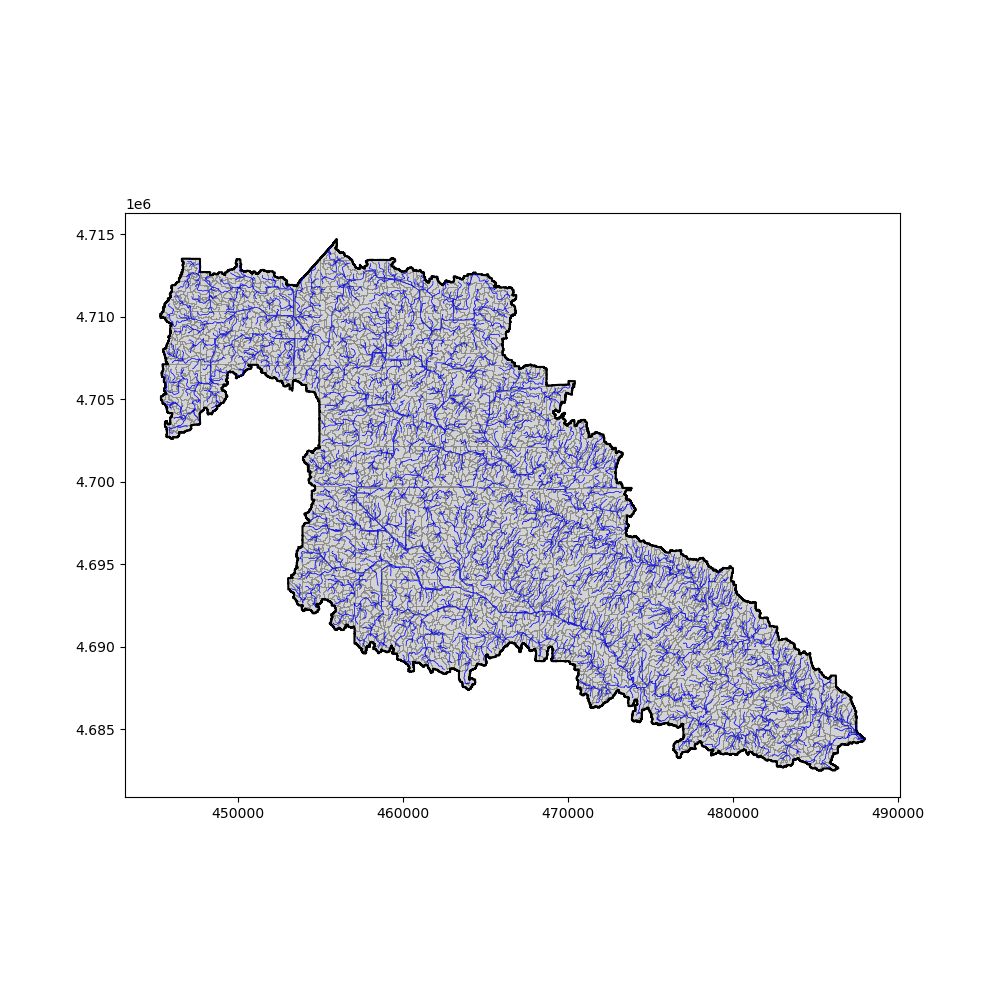

In [ ]:
plt.close('all')
fig, ax = plt.subplots(figsize = (10, 10))

hillslopes_watershed.plot(ax = ax, color = 'lightgray', linewidth = 0.5, edgecolor = 'grey')
watershed.boundary.plot(ax = ax, color = 'black')
rn_watershed.plot(ax = ax, color = 'blue', linewidth = 0.5)

In [71]:
hillslopes_watershed.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 4961 entries, 639913 to 767082
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LINKNO    4961 non-null   int32   
 1   area      4961 non-null   float64 
 2   geometry  4961 non-null   geometry
dtypes: float64(1), geometry(1), int32(1)
memory usage: 135.7 KB


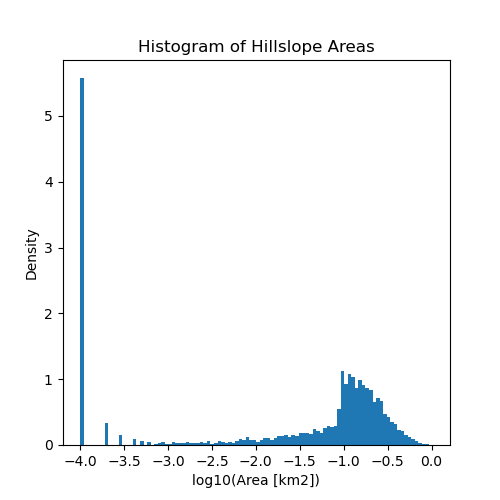

In [82]:
fig, ax = plt.subplots(figsize = (5, 5))

areas_km2 = hillslopes_watershed['area'].values*1e-6

_ = ax.hist(np.log10(areas_km2), bins = 100, density = True)
ax.set_xlabel('log10(Area [km2])')
ax.set_ylabel('Density')
ax.set_title('Histogram of Hillslope Areas')
plt.show()




In [78]:
areas

array([224870.388, 232876.639,  24818.816, ..., 235989.02 , 146717.438,
        90172.196], shape=(4961,))

In [77]:
hillslopes_watershed.area.values

array([224701.35450002, 232701.40272434,  24800.14949543, ...,
       235801.42141157, 146600.88371042,  90100.54312626], shape=(4961,))